# **import libraries and load the data set**

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as fashion_mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
# Load the Fashion MNIST dataset
# Train
train_fashion_mnist = fashion_mnist.as_numpy(fashion_mnist.load("fashion_mnist", split="train", batch_size=-1))
X_train, y_train = train_fashion_mnist["image"], train_fashion_mnist["label"]
# Test
test_fashion_mnist = fashion_mnist.as_numpy(fashion_mnist.load("fashion_mnist", split="test", batch_size=-1))
X_test, y_test = test_fashion_mnist["image"], test_fashion_mnist["label"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.94RKPS_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.94RKPS_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
# Print the number of training and test samples
print("Train Samples:", len(X_train))
print("Test Samples:", len(X_test))
# Define fashion classes
fashion_classes = {0: 'T-shirt/top',
                   1: 'Trouser',
                   2: 'Pullover',
                   3: 'Dress',
                   4: 'Coat',
                   5: 'Sandal',
                   6: 'Shirt',
                   7: 'Sneaker',
                   8: 'Bag',
                   9: 'Ankle boot'}

Train Samples: 60000
Test Samples: 10000


# **Data Preprocessing**

In [ ]:
# Check for any missing values in the dataset
if np.any(np.isnan(X_train)) or np.any(np.isnan(y_train)):
    print("Found missing values in training data.")
if np.any(np.isnan(X_test)) or np.any(np.isnan(y_test)):
    print("Found missing values in testing data.")

In [ ]:
# Define the options for data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,         # Randomly rotate images within 10 degrees
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill new pixels with the nearest pixel values
)

# Function to preprocess data
def preprocess_data(images, use_augmentation=False):
    X = []
    for x_ in images:
        # Scale pixel values between 0.0-1.0
        x_ = x_ / 255.0
        # Data augmentation without increasing the number of images
        if use_augmentation:
            x_ = next(datagen.flow(x_.reshape(1, 28, 28, 1), batch_size=1))[0]
        X.append(x_)
    return np.array(X)

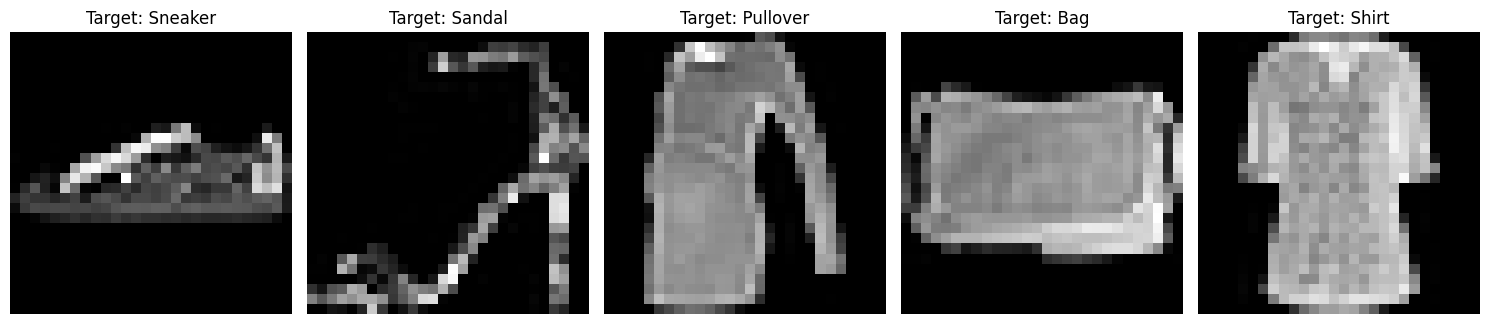

In [ ]:
# Visualizing 5 random images
num_images = 5
indices = np.random.randint(len(X_train), size=num_images)
# Create a figure with subplots
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for ax, idx in zip(axes, indices):
    ax.imshow(np.squeeze(X_train[idx]), cmap='gray')
    ax.axis('off')  # Turn off axis
    ax.set_title(f"Target: {fashion_classes[y_train[idx]]}")

plt.tight_layout()
plt.show()

In [ ]:
# Preprocess training and test data
X_train_shaped = preprocess_data(X_train, use_augmentation=True).reshape((X_train.shape[0], 28, 28, 1))
X_test_shaped = preprocess_data(X_test).reshape((X_test.shape[0], 28, 28, 1))
# One-hot encode labels
y_train_shaped = tf.keras.utils.to_categorical(y_train)
y_test_shaped = tf.keras.utils.to_categorical(y_test)

In [ ]:
# Flatten the training and test data for traditional classifiers
X_train_flat = X_train_shaped.reshape((X_train_shaped.shape[0], 28 * 28))
X_test_flat = X_test_shaped.reshape((X_test_shaped.shape[0], 28 * 28))

In [ ]:
# Split data for training and validation
X_train_, X_val_, y_train_, y_val_ = train_test_split(X_train_shaped, y_train_shaped, test_size=0.2, random_state=42)
X_train_flat_, X_val_flat_, y_train_flat_, y_val_flat_ = train_test_split(X_train_flat, y_train_shaped, test_size=0.2, random_state=42)

# Bulid CNN Model and tray different epoche and plot **results**

In [ ]:
# Import the necessary layers from Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
# Building a CNN model
cnn = Sequential()
cnn.add(InputLayer(input_shape=(28, 28, 1)))  # Input layer

# Normalization
cnn.add(BatchNormalization())

# Conv + Maxpooling
cnn.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Dropout
cnn.add(Dropout(0.1))

# Conv + Maxpooling
cnn.add(Conv2D(64, (3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Dropout
cnn.add(Dropout(0.3))

# Converting 3D feature to 1D feature vector
cnn.add(Flatten())

# Fully Connected Layer
cnn.add(Dense(256, activation='relu'))

# Dropout
cnn.add(Dropout(0.5))

# Fully Connected Layer
cnn.add(Dense(64, activation='relu'))

# Normalization
cnn.add(BatchNormalization())

# Output Layer
cnn.add(Dense(10, activation='softmax'))

# Compile the CNN model
cnn.compile(loss='categorical_crossentropy', optimizer=tf.optimizers.Adam(), metrics=['accuracy'])

# Print the model summary
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ (None, 28, 28, 1)           │               4 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 645,006 (2.46 MB)

 Trainable params: 644,876 (2.46 MB)

 Non-trainable params: 130 (520.00 B)

# Model: Sequential
# Summary of each layer in the CNN model architecture:

# 1. Batch Normalization:
#    - Normalizes input data (shape: 28x28 with 1 channel) to stabilize training.
#    - Parameters: 4

# 2. Conv2D (Convolutional Layer):
#    - A convolutional layer with 64 filters of size 3x3.
#    - Output shape: 28x28 with 64 channels.
#    - Parameters: 640

# 3. Max Pooling 2D:
#    - Reduces spatial dimensions to 14x14, preserving depth.
#    - Parameters: 0

# 4. Dropout:
#    - Randomly disables some connections to reduce overfitting.
#    - Parameters: 0

# 5. Conv2D (Second Convolutional Layer):
#    - Another convolutional layer with 64 filters of size 3x3.
#    - Output shape: 12x12 with 64 channels.
#    - Parameters: 36,928

# 6. Max Pooling 2D (Second Max Pooling):
#    - Further reduces dimensions to 6x6, maintaining depth.
#    - Parameters: 0

# 7. Dropout:
#    - Second dropout layer for regularization.
#    - Parameters: 0

# 8. Flatten:
#    - Flattens the 3D input to a 1D vector (2304 units).
#    - Parameters: 0

# 9. Dense:
#    - A dense (fully connected) layer with 256 units.
#    - Parameters: 590,080

# 10. Dropout:
#    - Third dropout layer to prevent overfitting.
#    - Parameters: 0

# 11. Dense:
#    - Dense layer with 64 units.
#    - Parameters: 16,448

# 12. Batch Normalization:
#    - Normalizes output from the previous layer.
#    - Parameters: 256

# 13. Dense (Output Layer):
#    - Final dense layer with 10 units (one for each class).
#    - Parameters: 650

# Total Parameters: 645,006 (2.46 MB)
# - Trainable Parameters: 644,876 (2.46 MB)
# - Non-trainable Parameters: 130 (520.00 B)


In [ ]:
# Train the CNN model using augmented data 10 epochs
cnn_history = cnn.fit(
    X_train_, y_train_,
    batch_size=250,
    epochs=10,
    verbose=1,
    validation_data=(X_val_, y_val_),
)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 114s 571ms/step - accuracy: 0.6132 - loss: 1.1082 - val_accuracy: 0.7984 - val_loss: 1.2126
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 108s 565ms/step - accuracy: 0.8290 - loss: 0.4737 - val_accuracy: 0.8723 - val_loss: 0.4013
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 144s 573ms/step - accuracy: 0.8569 - loss: 0.3962 - val_accuracy: 0.8738 - val_loss: 0.3360
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 118s 616ms/step - accuracy: 0.8724 - loss: 0.3461 - val_accuracy: 0.8878 - val_loss: 0.3020
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 134s 574ms/step - accuracy: 0.8825 - loss: 0.3245 - val_accuracy: 0.8823 - val_loss: 0.3080
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 142s 577ms/step - accuracy: 0.8888 - loss: 0.3001 - val_accuracy: 0.8939 - val_loss: 0.2832
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 143s 583ms/step - accuracy: 0.8937 - loss: 0.2874 - val_accuracy: 0.8963 - val_loss: 0.2775
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 146s 604ms/step - accuracy: 0.8992 -

In [ ]:
# Try more epochs 20
cnn_history3 = cnn.fit(
    X_train_, y_train_,
    batch_size=250,
    epochs=20,
    verbose=1,
    validation_data=(X_val_, y_val_)
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 113s 587ms/step - accuracy: 0.9081 - loss: 0.2485 - val_accuracy: 0.9044 - val_loss: 0.2579
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 148s 620ms/step - accuracy: 0.9120 - loss: 0.2366 - val_accuracy: 0.9084 - val_loss: 0.2586
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 135s 584ms/step - accuracy: 0.9156 - loss: 0.2227 - val_accuracy: 0.9092 - val_loss: 0.2517
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 142s 585ms/step - accuracy: 0.9189 - loss: 0.2162 - val_accuracy: 0.9082 - val_loss: 0.2481
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 110s 574ms/step - accuracy: 0.9218 - loss: 0.2097 - val_accuracy: 0.9122 - val_loss: 0.2443
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 149s 610ms/step - accuracy: 0.9230 - loss: 0.2075 - val_accuracy: 0.9112 - val_loss: 0.2540
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 144s 623ms/step - accuracy: 0.9175 - loss: 0.2078 - val_accuracy: 0.9111 - val_loss: 0.2538
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 135s 587ms/step - accuracy: 0.9255 -

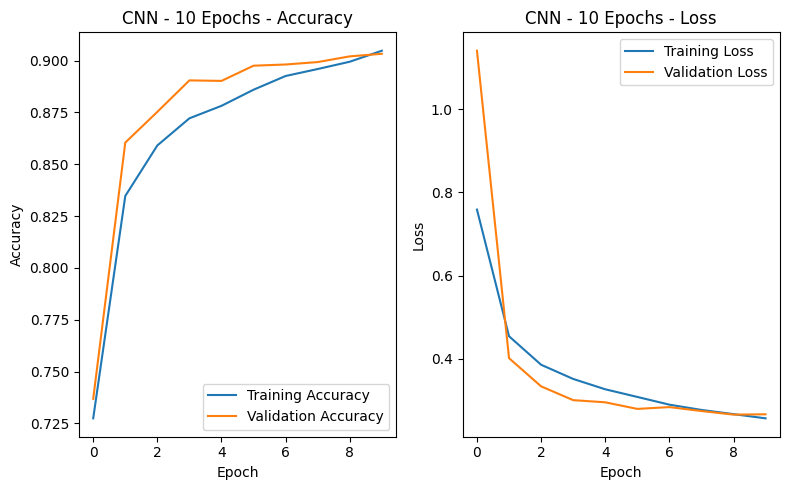

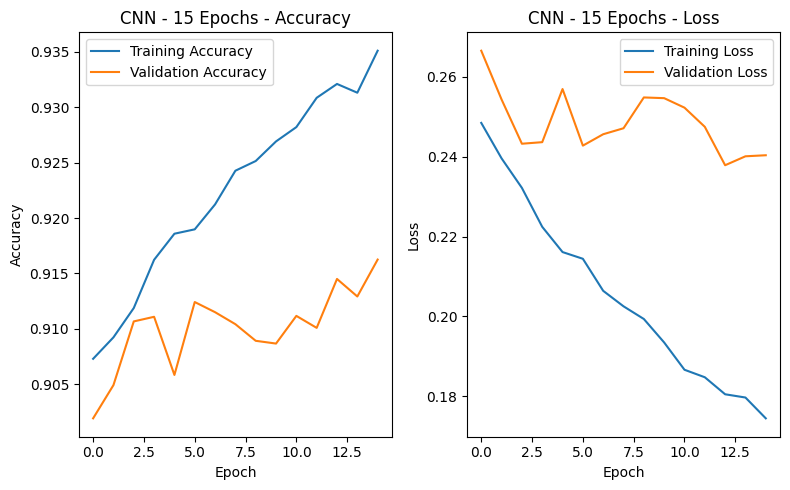

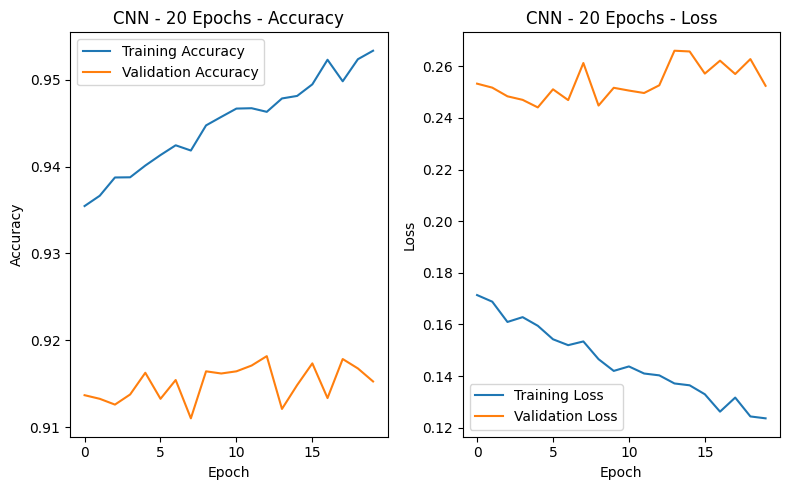

In [ ]:
# Plotting accuracy and loss curves for the CNN model
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(8, 5))

    # plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function for each model to illustrate the results of each configuration
plot_history(cnn_history, 'CNN - 10 Epochs')
plot_history(cnn_history2, 'CNN - 15 Epochs')
plot_history(cnn_history3, 'CNN - 20 Epochs')

# Adversarial examples in the physical


In [ ]:
import tensorflow as tf
import numpy as np
!pip install cleverhans
from cleverhans.tf2.attacks.fast_gradient_method import fast_gradient_method
import matplotlib.pyplot as plt

Accuracy on clean data: 91.45%
Accuracy on adversarial data (epsilon=0.05): 42.19%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


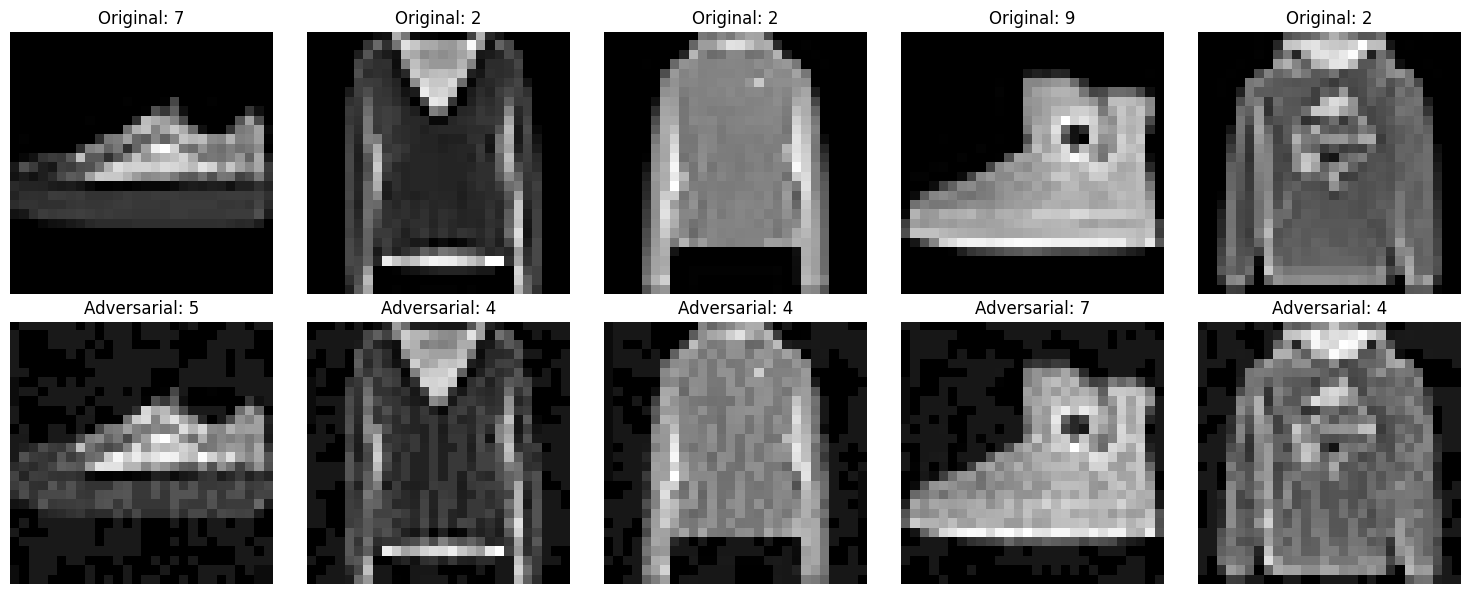

In [ ]:
# Craft adversarial examples using FGSM
def craft_adversarial_examples(model, X_test, epsilon):
    return fast_gradient_method(model_fn=model, x=X_test, eps=epsilon, norm=np.inf)

# Evaluate the model and visualize results
def evaluate_and_visualize(model, X_test, y_test, epsilon):
    # Accuracy on clean data
    clean_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f"Accuracy on clean data: {clean_acc * 100:.2f}%")

    # Generate adversarial examples
    X_adv = craft_adversarial_examples(model, X_test, epsilon)
    adv_acc = model.evaluate(X_adv, y_test, verbose=0)[1]
    print(f"Accuracy on adversarial data (epsilon={epsilon}): {adv_acc * 100:.2f}%")

    # Visualize original and adversarial images
    indices = np.random.choice(len(X_adv), 5, replace=False)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, idx in enumerate(indices):
        # Original images
        axes[0, i].imshow(np.squeeze(X_test[idx]), cmap='gray')
        axes[0, i].set_title(f"Original: {np.argmax(y_test[idx])}")
        axes[0, i].axis('off')

        # Adversarial images
        axes[1, i].imshow(np.squeeze(X_adv[idx]), cmap='gray')
        axes[1, i].set_title(f"Adversarial: {np.argmax(model.predict(X_adv[idx:idx+1]))}")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the adversarial attack
epsilon = 0.05
evaluate_and_visualize(cnn, X_test_shaped, y_test_shaped, epsilon)
